# Data & Libraries

In [141]:
import sys
sys.path.insert(1,'../Bike_Sharing_Demande/DATA/train.csv')

# Import Dependencies
%matplotlib inline

# Start Python Imports
import statistics as stats
import math, time, random
from datetime import datetime 
import calendar

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization 
import matplotlib.pyplot as plt
import missingno
import seaborn as sns
plt.style.use('seaborn-whitegrid')

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, label_binarize

# Machine learning
import catboost
from sklearn.model_selection import train_test_split
from sklearn import model_selection, tree, preprocessing, metrics, linear_model
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier, Pool, cv

# Let's be rebels and ignore warnings for now
import warnings
warnings.filterwarnings('ignore')

In [142]:
train_df = pd.read_csv('../Bike_Sharing_Demande/DATA/train.csv')
test_df = pd.read_csv('../Bike_Sharing_Demande/DATA/test.csv')
sample_df = pd.read_csv('../Bike_Sharing_Demande/DATA/sampleSubmission.csv')

# Analyse
Description des données :
- datetime - hourly date + timestamp  
- season -  1 = spring, 2 = summer, 3 = fall, 4 = winter 
- holiday - whether the day is considered a holiday
- workingday - whether the day is neither a weekend nor holiday
- weather - 
    - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
    - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
    - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog 
- temp - temperature in Celsius
- atemp - "feels like" temperature in Celsius
- humidity - relative humidity
- windspeed - wind speed
- casual - number of non-registered user rentals initiated
- registered - number of registered user rentals initiated
- count - number of total rentals

In [143]:
train_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [144]:
test_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014


## Feature Engineering 

In [145]:
# Création d'une nouvelle colonne date 
train_df['date']= train_df.datetime.apply(lambda x: x.split()[0])
train_df['hour'] = train_df.datetime.apply(lambda x: x.split()[1].split(":")[0])
train_df['weekday'] = train_df.date.apply(lambda dateString : calendar.day_name[datetime.strptime(dateString,"%Y-%m-%d").weekday()])
train_df['month'] = train_df.date.apply(lambda dateString : calendar.month_name[datetime.strptime(dateString,"%Y-%m-%d").weekday()])
train_df['season'] = train_df.season.map({1: "Spring", 2: "Summer",3: "Fall",4: "Winter"})
train_df["weather"] = train_df.weather.map({1: " Clear + Few clouds + Partly cloudy + Partly cloudy",\
                                        2 : " Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist ", \
                                        3 : " Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds", \
                                        4 :" Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog " })

In [146]:
train_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,hour,weekday,month
0,2011-01-01 00:00:00,Spring,0,0,Clear + Few clouds + Partly cloudy + Partly cloudy,9.84,14.395,81,0.0,3,13,16,2011-01-01,00,Saturday,May
1,2011-01-01 01:00:00,Spring,0,0,Clear + Few clouds + Partly cloudy + Partly cloudy,9.02,13.635,80,0.0,8,32,40,2011-01-01,01,Saturday,May
2,2011-01-01 02:00:00,Spring,0,0,Clear + Few clouds + Partly cloudy + Partly cloudy,9.02,13.635,80,0.0,5,27,32,2011-01-01,02,Saturday,May
3,2011-01-01 03:00:00,Spring,0,0,Clear + Few clouds + Partly cloudy + Partly cloudy,9.84,14.395,75,0.0,3,10,13,2011-01-01,03,Saturday,May
4,2011-01-01 04:00:00,Spring,0,0,Clear + Few clouds + Partly cloudy + Partly cloudy,9.84,14.395,75,0.0,0,1,1,2011-01-01,04,Saturday,May


In [147]:
# Conversion en type categorical 
categoryVariableList = ['hour','weekday','month','season','weather','holiday','workingday']

for var in categoryVariableList:
    train_df[var] = train_df[var].astype("category")

In [148]:
# Drop date columns 
train_df = train_df.drop(['datetime'], axis = 1 )

## Missing value 

<AxesSubplot:>

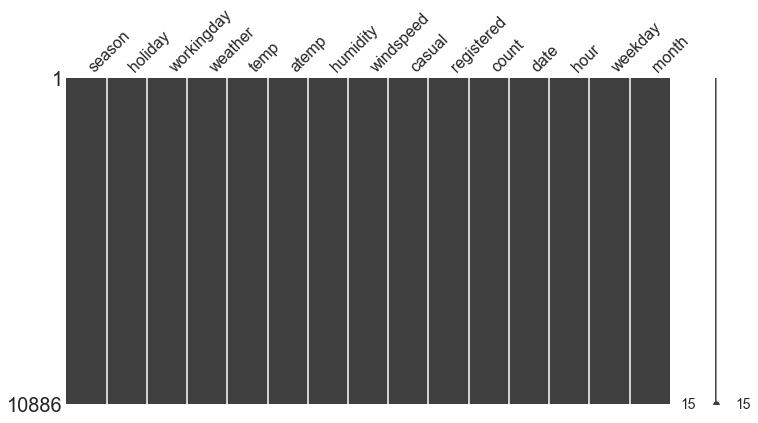

In [149]:
missingno.matrix(train_df,figsize=(12,6))

## Outliers

Observation
- Lorsque l'on regarde la distribution de la variable `count`il est possible de voir que celle-ci est `right-skewed` (fig 1) 
- Le printemps présente un nombre de fréquentation plus faible que les autres saisons
- Lorsqu'on regarde le boxplot des heures, il est possible de voir des fréquentations plus importantes sur certaines créneau de la journée : 
    - 7-8h 
    - 17-18h
    > Cause de la fréquentation : les personnes prennent le vélo pour se rendre au travail et pour y rentrer
- Les valeurs aberrantes sont plus présentent dans les `jours non ouvrables` (working day = 1 )

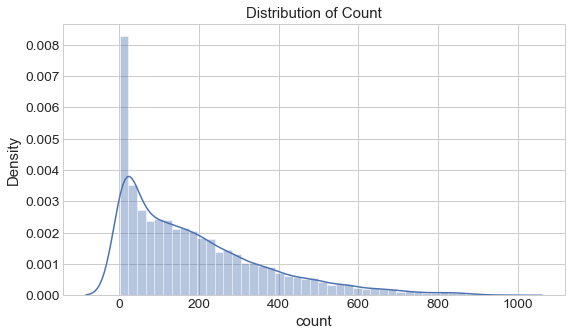

In [150]:
fig  = plt.figure(figsize=(9,5))
sns.distplot(train_df['count']).set_title('Distribution of Count')
sns.set(font_scale=1)

Text(0.5, 1.0, 'Working day')

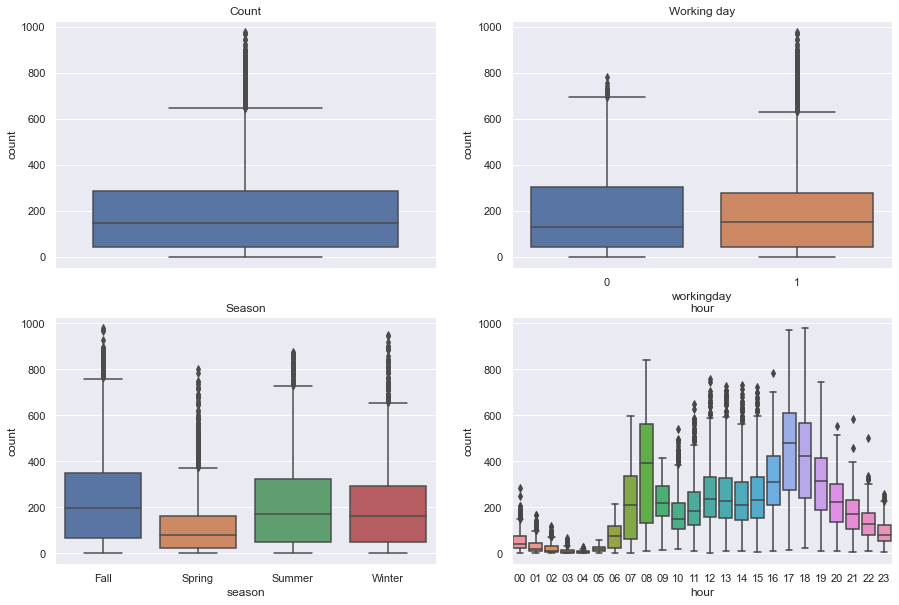

In [151]:
fig, axes = plt.subplots(nrows = 2, ncols = 2)
fig.set_size_inches(15,10)


# Fonction boxplot axes = position plot
sns.boxplot(data = train_df,y = 'count',orient = 'v',ax = axes[0][0]).set_title('Count')
sns.boxplot(data = train_df,y = 'count',x = 'season',orient = 'v',ax = axes[1][0]).set_title('Season')
sns.boxplot(data = train_df,y = 'count',x = 'hour',orient = 'v',ax = axes[1][1]).set_title('hour')
sns.boxplot(data = train_df,y = 'count',x = 'workingday',orient = 'v',ax = axes[0][1]).set_title('Working day')

## Removing Outliers of Count

In [152]:
new_train_df = train_df[np.abs(train_df['count']-train_df['count'].mean())<=(3*train_df['count'].std())]


In [153]:
print('Shape with Outlires', train_df.shape)
print('Shape without outliers',new_train_df.shape)

Shape with Outlires (10886, 15)
Shape without outliers (10739, 15)


## Correlation Analysis

<AxesSubplot:>

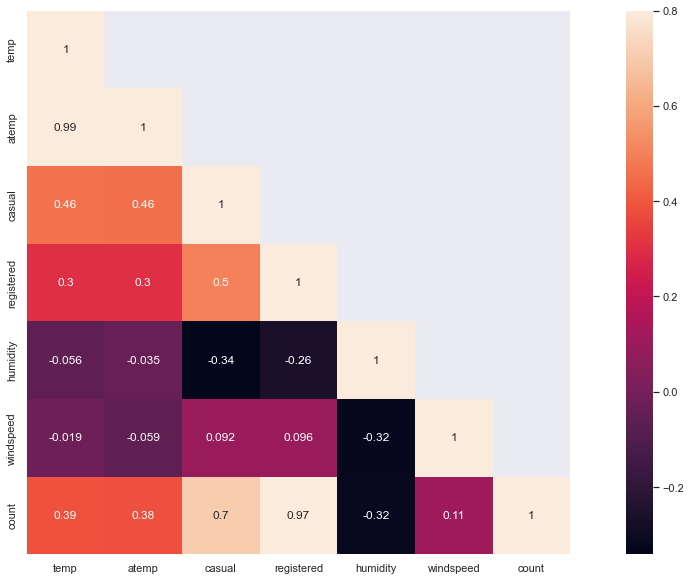

In [154]:
corrMatt = new_train_df[['temp','atemp','casual','registered','humidity','windspeed','count']].corr()
mask = np.array(corrMatt)
mask[np.tril_indices_from(mask)] = False
fig,ax= plt.subplots()
fig.set_size_inches(20,10)
sns.heatmap(corrMatt, mask=mask,vmax=.8, square=True,annot=True)
